# 04 · Auction Design from Equilibrium to Credible Deployment
**COMSCI/ECON 206 · Computational Microeconomics · Autumn 2026**  
**Instructor: Prof. Luyao Zhang**

This notebook is the computational companion to the Week 5 slides and the two-page **Strategic Thinking and Auction Application Map**. It begins with the Week 1–3 game-class decision, solves five auction formats under explicit assumptions, compares design objectives, and then breaks the benchmark through behavior, risk, common values, budgets, resale, collusion, and seller mistrust.

> **Human-led protocol:** predict first → record your reasoning → run the code → inspect an invariant or counterexample → change one assumption → explain what changed → disclose any AI assistance.

## Coverage map

| Slide / sheet requirement | Computational evidence here |
|---|---|
| Static/dynamic × complete/incomplete information | §1 classifier and solution-concept map |
| NE, BNE, SPNE, PBE, and DSIC | §1 definitions; §4–5 incentive checks |
| First-price, second-price, English, Dutch, all-pay | §3 shared implementation and replay |
| Revenue equivalence | §6 seeded Monte Carlo check against $(n-1)/(n+1)$ |
| Revenue, efficiency, welfare, IR, budget balance, fairness | §7 objective dashboard |
| Bounded rationality, risk, winner's curse, budgets, reserves | §8 stress tests |
| Resale, collusion, and credible execution | §9 institutional stress tests |
| Economics, CS, behavioral science, global leadership | §10 model–people–system–institution audit |

**Learning evidence:** one prediction, one executed baseline, one changed assumption, one invariant or counterexample, and one bounded interpretation.

## 1. Classify the game before choosing a solver

| Timing and information | Natural representation | Baseline solution concept | Auction example |
|---|---|---|---|
| Static + complete | Normal form / payoff matrix | Nash equilibrium (NE) | A stylized bid-choice game with known values and payoffs |
| Static + incomplete | Bayesian normal form: types, prior, type-contingent strategies | Bayesian Nash equilibrium (BNE) | First-price, second-price, or all-pay sealed bid |
| Dynamic + complete | Extensive-form game tree | Subgame-perfect Nash equilibrium (SPNE) | A complete-information stopping or entry game |
| Dynamic + incomplete | Tree + Nature + information sets + beliefs | Perfect Bayesian equilibrium (PBE) or sequential equilibrium | English ascending or Dutch descending auction |

- **NE:** no player gains from a unilateral strategy change while rivals' strategies stay fixed.
- **BNE:** every private type chooses a best response in expectation over rivals' types.
- **SPNE:** strategies form an NE after every history that begins a proper subgame.
- **PBE:** strategies are sequentially rational at every information set and beliefs obey Bayes' rule wherever possible on path. Use **PBE**, not “BPE.”
- **Dominant-strategy incentive compatibility (DSIC):** truthful reporting is optimal for every rivals' report. It is stronger than truthfulness only in expectation under BNE.

### Intellectual lineage used in the slides

| Prize year | Laureate(s) | What becomes visible in this notebook |
|---:|---|---|
| 1994 | John Nash, Reinhard Selten, John Harsanyi | Mutual best responses, credible continuation play, and private types |
| 1996 | William Vickrey | Truthful second-price bidding and asymmetric information |
| 2002 | Vernon Smith | Laboratory tests of how people actually use market mechanisms |
| 2007 | Leonid Hurwicz, Eric Maskin, Roger Myerson | Mechanism design, incentive constraints, and optimal rules |
| 2020 | Paul Milgrom, Robert Wilson | Common values, information, winner's curse, and new auction formats |

**Decision rule:** do not choose BNE because “auction” appears in the title. First ask whether actions are simultaneous or sequential, what is observed, and what payoff-relevant information is private.

### Code 1 · Reproducible environment

| Technical cue | Meaning |
|---|---|
| **Purpose** | Fix versions, random seed, plotting style, and display precision |
| **Inputs** | Installed NumPy, pandas, and Matplotlib packages |
| **Outputs** | A visible environment record |
| **Assumptions** | CPU execution; no external data or API key |
| **Interpretation** | A result is reproducible only when its environment and random state are documented |

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 206
rng = np.random.default_rng(SEED)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"navy": "#14213d", "cyan": "#1aa6b7", "violet": "#7656c9", "green": "#1c9c75", "coral": "#e45756", "gold": "#d99a1b"}
pd.options.display.float_format = "{:,.3f}".format

display(pd.DataFrame({
    "component": ["Python", "NumPy", "pandas", "Matplotlib", "random seed"],
    "version / value": [platform.python_version(), np.__version__, pd.__version__, matplotlib.__version__, SEED],
}))

,component,version / value
0,Python,3.12.14
1,NumPy,2.3.5
2,pandas,2.2.3
3,Matplotlib,3.10.8
4,random seed,206


## 2. Baseline model and notation

There are $n\geq2$ bidders and one indivisible item. Bidder $i$ has private type/value $v_i\sim\mathrm{Uniform}[0,1]$, submits action $b_i$, receives allocation $x_i\in\{0,1\}$, and pays $p_i$.

$$u_i(v_i,b_i,b_{-i})=x_i(b_i,b_{-i})v_i-p_i(b_i,b_{-i}).$$

**Shared benchmark:** symmetric risk-neutral bidders; independent private values (IPV); no reserve, budget constraint, entry cost, collusion, resale, or seller deviation. The code changes one assumption at a time later.

| Format | Game class + representation | Solution concept | Benchmark action |
|---|---|---|---|
| First price | Static incomplete; Bayesian normal form | BNE | $b(v)=\frac{n-1}{n}v$ |
| Second price | Static incomplete; direct mechanism | DSIC (therefore BNE) | $b(v)=v$ |
| English | Dynamic incomplete; observed price history | PBE / sequential rationality | stay while $p<v$; exit at $p=v$ |
| Dutch | Dynamic incomplete; stopping game | PBE; first-price outcome equivalence | stop at $p(v)=\frac{n-1}{n}v$ |
| All pay | Static incomplete; every bid paid | BNE | $b(v)=\frac{n-1}{n}v^n$ |

### Code 2 · Machine-readable mechanism map

| Technical cue | Meaning |
|---|---|
| **Purpose** | Keep classification, rule, and solution concept attached to every computation |
| **Inputs** | Five formats from the Week 5 sheet |
| **Outputs** | A comparison table used as a preflight before simulation |
| **Assumptions** | Labels describe the stated benchmark, not every possible auction variant |
| **Interpretation** | A program can execute a payment rule without proving its equilibrium |

In [2]:
AUCTION_SPECS = {
    "first_price": ("static + incomplete", "Bayesian normal form", "BNE", "highest bid wins; winner pays own bid"),
    "second_price": ("static + incomplete", "direct mechanism", "DSIC → BNE", "highest bid wins; winner pays second bid"),
    "english": ("dynamic + incomplete", "tree + price history + beliefs", "PBE / sequential", "stay until price reaches value under IPV"),
    "dutch": ("dynamic + incomplete", "stopping game", "PBE", "first stop wins and pays clock price"),
    "all_pay": ("static + incomplete", "Bayesian normal form", "BNE", "highest bid wins; every bidder pays"),
}
specs = pd.DataFrame.from_dict(AUCTION_SPECS, orient="index", columns=["game class", "representation", "solution", "rule"])
specs.index.name = "format"
display(specs)

,game class,representation,solution,rule
format,,,,
first_price,static + incomplete,Bayesian normal form,BNE,highest bid wins; winner pays own bid
second_price,static + incomplete,direct mechanism,DSIC → BNE,highest bid wins; winner pays second bid
english,dynamic + incomplete,tree + price history + beliefs,PBE / sequential,stay until price reaches value under IPV
dutch,dynamic + incomplete,stopping game,PBE,first stop wins and pays clock price
all_pay,static + incomplete,Bayesian normal form,BNE,highest bid wins; every bidder pays


## 3. One transparent auction engine

**Pseudocode specification**

1. Validate values, bids, budgets, reserve, and format.  
2. Cap each submitted bid at its executable budget.  
3. Allocate to the highest eligible bid; a fixed index breaks exact ties for reproducibility.  
4. Apply the format's payment rule.  
5. Compute utility, seller revenue, welfare, allocative efficiency, loser-payment burden, ex-post individual rationality, and budget balance.  
6. Hold rivals' bids fixed and search unilateral deviations to calculate **realized ex-post regret**.

> Ex-post regret and BNE answer different questions. Positive realized regret after types are revealed does **not** refute a Bayesian equilibrium, which maximizes expected utility before rivals' types are known.

### Code 3 · Allocation, payments, and diagnostics

| Technical cue | Meaning |
|---|---|
| **Purpose** | Implement all five formats with one auditable interface |
| **Inputs** | Values/signals, bids, format, reserve, budgets, optional common value |
| **Outputs** | Winner, payments, utilities, revenue, welfare, efficiency, IR, and loser burden |
| **Assumptions** | Deterministic lowest-index tie break; transfers are excluded from total welfare |
| **Interpretation** | Each metric is a diagnostic; “fairness” still requires an explicit normative criterion |

In [3]:
FORMATS = tuple(AUCTION_SPECS)

def benchmark_bids(values, auction_format, risk_aversion=0.0):
    '''Return the Week 5 symmetric benchmark for values in [0,1].'''
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n < 2 or auction_format not in FORMATS:
        raise ValueError("Use at least two bidders and a listed format.")
    if not 0 <= risk_aversion < 1:
        raise ValueError("The illustrative CRRA coefficient must be in [0,1).")
    if auction_format in {"second_price", "english"}:
        return values.copy()                         # Truth / exit threshold under IPV.
    if auction_format in {"first_price", "dutch"}:
        return ((n - 1) / (n - risk_aversion)) * values
    return ((n - 1) / n) * values ** n              # Risk-neutral all-pay benchmark.

def auction_outcome(values, bids, auction_format, reserve=0.0, budgets=None, common_value=None):
    '''Execute allocation/payment rules; this function does not itself prove equilibrium.'''
    values, bids = np.asarray(values, float), np.asarray(bids, float)
    if len(values) < 2 or len(values) != len(bids) or auction_format not in FORMATS:
        raise ValueError("Values and bids must have the same length ≥2 and use a listed format.")
    budgets = np.full(len(values), np.inf) if budgets is None else np.asarray(budgets, float)
    if len(budgets) != len(values) or np.any(values < 0) or np.any(bids < 0) or np.any(budgets < 0):
        raise ValueError("Values, bids, and budgets must be aligned and non-negative.")
    effective = np.minimum(bids, budgets)             # A bid above budget cannot be executed.
    winner = int(np.argmax(effective)) if effective.max() + 1e-12 >= reserve else None
    payments = np.zeros(len(values))
    if auction_format == "all_pay":
        payments[:] = effective                      # Losing effort is still paid.
    elif winner is not None and auction_format in {"first_price", "dutch"}:
        payments[winner] = effective[winner]
    elif winner is not None:
        rival_max = np.max(np.delete(effective, winner))
        payments[winner] = max(reserve, rival_max)
    item_values = np.full(len(values), common_value) if common_value is not None else values
    utilities = -payments.copy()
    if winner is not None:
        utilities[winner] += item_values[winner]
    feasible = 0.0 if winner is None else float(np.max(item_values))
    realized = 0.0 if winner is None else float(item_values[winner])
    revenue = float(payments.sum())
    loser_burden = float(payments.sum() - (0 if winner is None else payments[winner]))
    return {
        "format": auction_format, "winner": winner, "values": values, "bids": bids,
        "effective_bids": effective, "payments": payments, "utilities": utilities,
        "revenue": revenue, "welfare": realized, "efficient_welfare": feasible,
        "efficiency": 1.0 if feasible == 0 else realized / feasible,
        "winner_is_highest_value": winner is not None and winner == int(np.argmax(values)),
        "loser_burden": loser_burden, "ex_post_IR": bool(np.all(utilities >= -1e-9)),
        "weak_budget_balance": revenue >= -1e-9, "reserve": float(reserve), "budgets": budgets,
    }

def unilateral_regret(values, bids, auction_format, reserve=0.0, budgets=None, common_value=None, grid_size=401):
    '''Hold rival bids fixed and find the best realized deviation for each bidder.'''
    baseline = auction_outcome(values, bids, auction_format, reserve, budgets, common_value)
    budgets = np.full(len(values), np.inf) if budgets is None else np.asarray(budgets, float)
    rows = []
    for bidder, value in enumerate(values):
        rivals = np.delete(np.asarray(bids, float), bidder)
        upper = min(budgets[bidder], max(1.2, 1.25 * value, 1.2 * rivals.max(), 1.2 * reserve))
        candidates = np.unique(np.r_[np.linspace(0, upper, grid_size), bids[bidder], value, rivals])
        best_utility, best_bid = baseline["utilities"][bidder], bids[bidder]
        for candidate in candidates:
            changed = np.array(bids, float); changed[bidder] = candidate
            utility = auction_outcome(values, changed, auction_format, reserve, budgets, common_value)["utilities"][bidder]
            if utility > best_utility + 1e-10:
                best_utility, best_bid = utility, candidate
        rows.append({"bidder": bidder + 1, "current bid": bids[bidder], "best realized bid": best_bid,
                     "current utility": baseline["utilities"][bidder], "best utility": best_utility,
                     "ex-post regret": max(0.0, best_utility - baseline["utilities"][bidder])})
    return pd.DataFrame(rows)

### Code 4 · Counterfactual replay across five formats

| Technical cue | Meaning |
|---|---|
| **Purpose** | Hold one value profile fixed and change only the mechanism |
| **Inputs** | Four values and each format's benchmark strategy |
| **Outputs** | Allocation, winning payment, revenue, welfare, loser burden, and IR |
| **Assumptions** | Baseline IPV environment; no reserve or budget cap |
| **Interpretation** | A realized revenue difference does not contradict revenue equivalence in expectation |

,winner,winning bid,winner payment,seller revenue,welfare,efficiency,loser burden,ex-post IR
format,,,,,,,,
first_price,1,0.690,0.690,0.690,0.920,1.000,0.000,True
second_price,1,0.920,0.730,0.730,0.920,1.000,0.000,True
english,1,0.920,0.730,0.730,0.920,1.000,0.000,True
dutch,1,0.690,0.690,0.690,0.920,1.000,0.000,True
all_pay,1,0.537,0.537,0.826,0.920,1.000,0.289,False


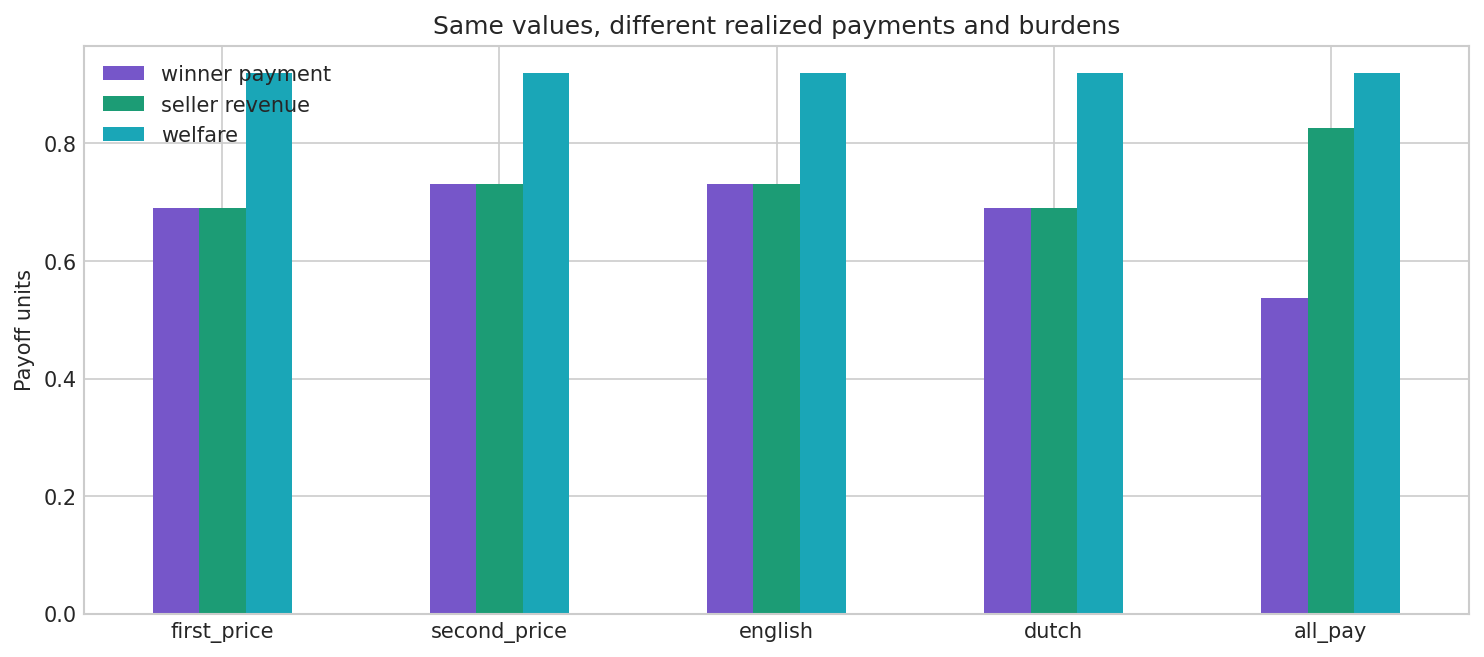

In [4]:
values = np.array([0.92, 0.73, 0.55, 0.31])
outcomes, rows = {}, []
for auction_format in FORMATS:
    bids = benchmark_bids(values, auction_format)
    outcome = auction_outcome(values, bids, auction_format)
    outcomes[auction_format] = outcome
    rows.append({
        "format": auction_format, "winner": outcome["winner"] + 1,
        "winning bid": outcome["effective_bids"][outcome["winner"]],
        "winner payment": outcome["payments"][outcome["winner"]],
        "seller revenue": outcome["revenue"], "welfare": outcome["welfare"],
        "efficiency": outcome["efficiency"], "loser burden": outcome["loser_burden"],
        "ex-post IR": outcome["ex_post_IR"],
    })
baseline_table = pd.DataFrame(rows).set_index("format")
display(baseline_table)

ax = baseline_table[["winner payment", "seller revenue", "welfare"]].plot(
    kind="bar", figsize=(10, 4.5), color=[COLORS["violet"], COLORS["green"], COLORS["cyan"]])
ax.set(title="Same values, different realized payments and burdens", ylabel="Payoff units", xlabel="")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 4. BNE and DSIC are different incentive tests

For a first-price auction, type $v$ solves an **expected** problem:

$$\max_b (v-b)F\!\left(\beta^{-1}(b)\right)^{n-1}.$$

For a second-price auction, truthful bidding passes a stronger **pointwise** test for every rivals' report $b_{-i}$:

$$u_i(v_i,v_i,b_{-i})\geq u_i(v_i,b_i,b_{-i})\quad\forall b_i,b_{-i}.$$

The next two cells visualize the distinction. A BNE bid can have positive regret after rival types are revealed; a DSIC report cannot be improved by a unilateral misreport for that realized rival profile.

### Code 5 · First-price expected best response

| Technical cue | Meaning |
|---|---|
| **Purpose** | Verify the symmetric BNE for one type by direct expected-utility search |
| **Inputs** | $v=0.8$, $n=4$, Uniform[0,1], rivals use $\beta(v)=3v/4$ |
| **Outputs** | Utility curve and numerical maximizer |
| **Assumptions** | Risk neutrality, symmetry, independence, continuous values |
| **Interpretation** | The optimum should lie near $\beta(0.8)=0.6$ |

Numerical best bid = 0.600; theoretical BNE bid = 0.600


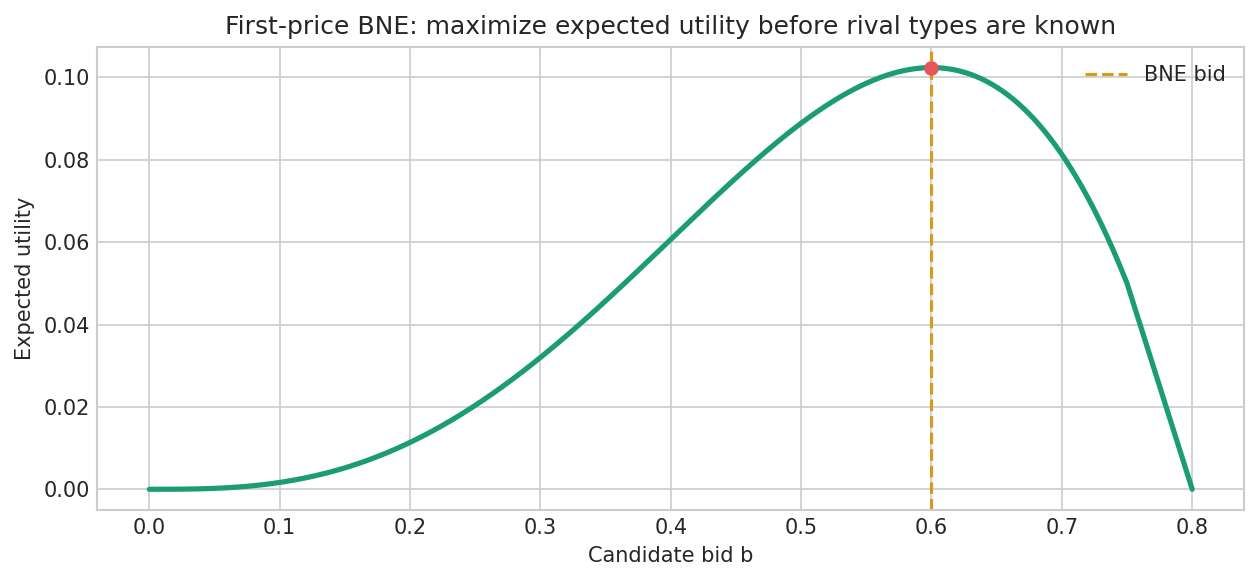

In [5]:
n, focal_value = 4, 0.80
candidate_bids = np.linspace(0, focal_value, 801)
inverse_types = np.clip(candidate_bids * n / (n - 1), 0, 1)
win_probability = inverse_types ** (n - 1)
expected_utility = (focal_value - candidate_bids) * win_probability
best_index = int(np.argmax(expected_utility))
theoretical_bid = (n - 1) / n * focal_value

print(f"Numerical best bid = {candidate_bids[best_index]:.3f}; theoretical BNE bid = {theoretical_bid:.3f}")
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(candidate_bids, expected_utility, color=COLORS["green"], linewidth=2.5)
ax.axvline(theoretical_bid, color=COLORS["gold"], linestyle="--", label="BNE bid")
ax.scatter([candidate_bids[best_index]], [expected_utility[best_index]], color=COLORS["coral"], zorder=3)
ax.set(title="First-price BNE: maximize expected utility before rival types are known", xlabel="Candidate bid b", ylabel="Expected utility")
ax.legend(); plt.tight_layout(); plt.show()

### Code 6 · Second-price ex-post deviation check

| Technical cue | Meaning |
|---|---|
| **Purpose** | Check the Vickrey threshold argument against a fixed highest rival bid |
| **Inputs** | Value $v=0.8$ and highest rival bid $0.62$ |
| **Outputs** | Utility for every candidate report and the truthful reference line |
| **Assumptions** | Private value, quasilinear utility, committed second-price execution |
| **Interpretation** | Truth is weakly optimal; other winning reports may tie it, so dominance is weak |

Truthful utility = 0.180; maximum over all reports = 0.180


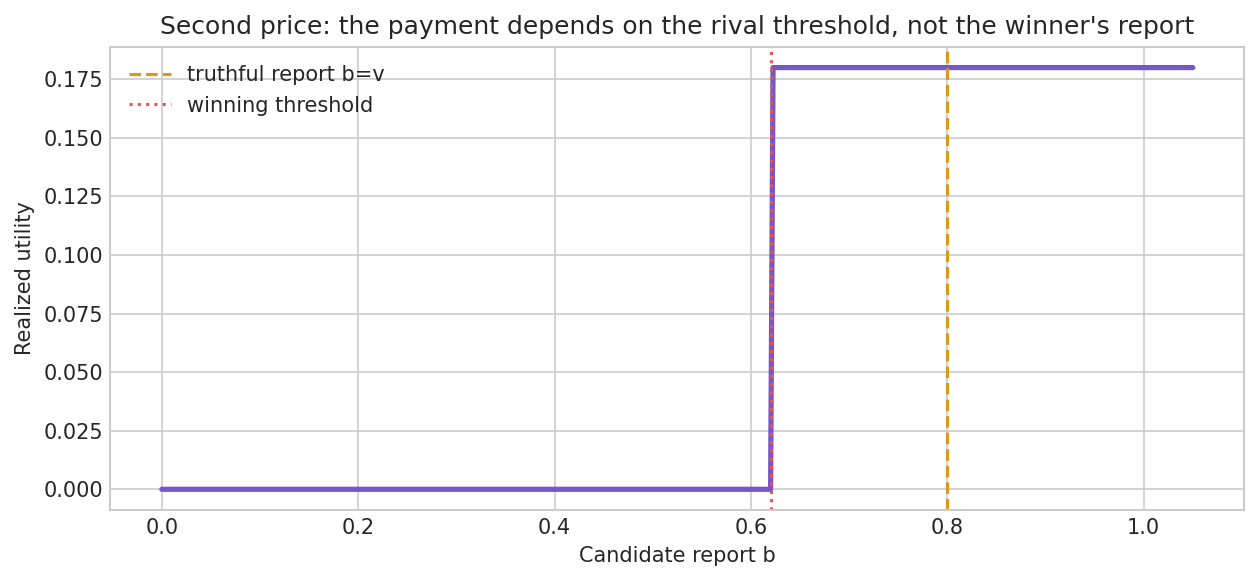

In [6]:
value, highest_rival = 0.80, 0.62
reports = np.linspace(0, 1.05, 421)
utilities = np.where(reports > highest_rival, value - highest_rival, 0.0)
truthful_utility = value - highest_rival
print(f"Truthful utility = {truthful_utility:.3f}; maximum over all reports = {utilities.max():.3f}")
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(reports, utilities, color=COLORS["violet"], linewidth=2.5)
ax.axvline(value, color=COLORS["gold"], linestyle="--", label="truthful report b=v")
ax.axvline(highest_rival, color=COLORS["coral"], linestyle=":", label="winning threshold")
ax.set(title="Second price: the payment depends on the rival threshold, not the winner's report", xlabel="Candidate report b", ylabel="Realized utility")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Dynamic auctions require histories and sequential rationality

- **English:** later stay/exit actions condition on the observed price history. Under IPV, remain active while $p<v$ and exit at $p=v$.
- **Dutch:** each bidder chooses a stopping rule. Under the benchmark, the stopping price matches the first-price bid function.
- **PBE check:** specify strategies at every information set and beliefs about private values; apply Bayes' rule wherever possible on path.

The compact clock trace below illustrates outcomes. It does not substitute for a full extensive-form proof.

### Code 7 · English dropout and Dutch stopping traces

| Technical cue | Meaning |
|---|---|
| **Purpose** | Turn a dynamic rule into an observable event history |
| **Inputs** | The same four private values |
| **Outputs** | Dropout/stopping order, winner, and implied price |
| **Assumptions** | IPV threshold strategies and continuous clocks |
| **Interpretation** | English resembles second price; Dutch resembles first price under the benchmark |

In [7]:
order = np.argsort(values)
english_trace = pd.DataFrame({
    "event": np.arange(1, len(values)),
    "price": values[order[:-1]],
    "bidder exiting": order[:-1] + 1,
    "bidders remaining": np.arange(len(values) - 1, 0, -1),
})
dutch_stops = benchmark_bids(values, "dutch")
dutch_order = np.argsort(-dutch_stops)
dutch_trace = pd.DataFrame({"stopping rank": np.arange(1, len(values) + 1), "bidder": dutch_order + 1, "stop price": dutch_stops[dutch_order]})
print(f"English winner: Bidder {np.argmax(values)+1}; price ≈ second value {np.sort(values)[-2]:.3f}")
display(english_trace)
print(f"Dutch winner: Bidder {dutch_order[0]+1}; first stop = {dutch_stops[dutch_order[0]]:.3f}")
display(dutch_trace)

English winner: Bidder 1; price ≈ second value 0.730
Dutch winner: Bidder 1; first stop = 0.690


,event,price,bidder exiting,bidders remaining
0,1,0.310,4,3
1,2,0.550,3,2
2,3,0.730,2,1


,stopping rank,bidder,stop price
0,1,1,0.690
1,2,2,0.547
2,3,3,0.413
3,4,4,0.232


## 6. Revenue Equivalence Theorem: expectation, not identical play

If two mechanisms implement the same allocation rule and give the lowest type the same expected utility, they induce the same interim expected payment under the benchmark assumptions.

$$m(v)=v\,x(v)-\int_0^v x(t)\,dt-U(0).$$

For $n$ Uniform[0,1] bidders, expected revenue is

$$\mathbb{E}[R^{FP}]=\mathbb{E}[R^{SP}]=\mathbb{E}[R^{EN}]=\mathbb{E}[R^{DU}]=\mathbb{E}[R^{AP}]=\frac{n-1}{n+1}.$$

### Code 8 · Seeded Monte Carlo verification

| Technical cue | Meaning |
|---|---|
| **Purpose** | Compare simulated average revenue with the theorem's closed form |
| **Inputs** | 50,000 value profiles, $n=4$, seed 206 |
| **Outputs** | Estimated revenue by format and absolute simulation gap |
| **Assumptions** | Every benchmark assumption listed in §2 remains active |
| **Interpretation** | Small sampling gaps are expected; systematic gaps motivate an assumption audit |

,simulation mean,theory,absolute gap
first_price,0.601,0.600,0.001
second_price,0.601,0.600,0.001
english,0.601,0.600,0.001
dutch,0.601,0.600,0.001
all_pay,0.601,0.600,0.001


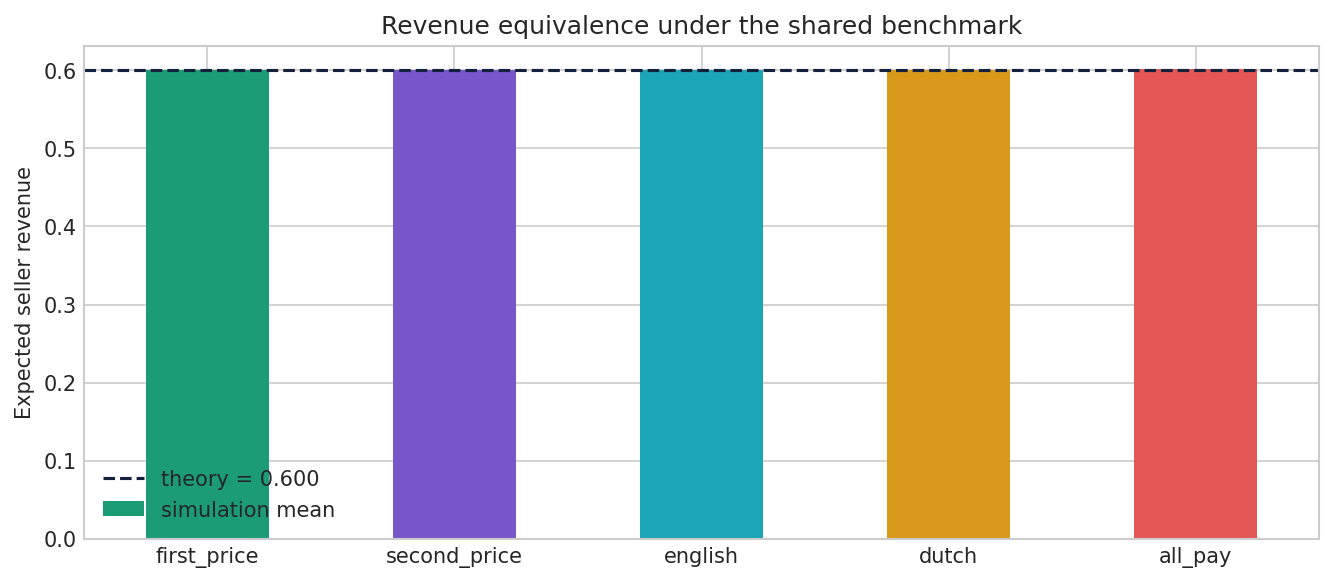

In [8]:
draws, n = rng.random((50_000, 4)), 4
ordered = np.sort(draws, axis=1)
revenues = pd.DataFrame({
    "first_price": ((n - 1) / n) * ordered[:, -1],
    "second_price": ordered[:, -2],
    "english": ordered[:, -2],
    "dutch": ((n - 1) / n) * ordered[:, -1],
    "all_pay": (((n - 1) / n) * draws ** n).sum(axis=1),
})
theory = (n - 1) / (n + 1)
revenue_summary = pd.DataFrame({"simulation mean": revenues.mean()})
revenue_summary["theory"] = theory
revenue_summary["absolute gap"] = (revenue_summary["simulation mean"] - theory).abs()
display(revenue_summary)

ax = revenue_summary["simulation mean"].plot(kind="bar", figsize=(9, 4), color=[COLORS["green"], COLORS["violet"], COLORS["cyan"], COLORS["gold"], COLORS["coral"]])
ax.axhline(theory, color=COLORS["navy"], linestyle="--", label=f"theory = {theory:.3f}")
ax.set(title="Revenue equivalence under the shared benchmark", ylabel="Expected seller revenue", xlabel="")
ax.tick_params(axis="x", rotation=0); ax.legend(); plt.tight_layout(); plt.show()

## 7. Evaluate more than revenue

- **Allocative efficiency:** does the feasible highest-value use receive the item?
- **Welfare:** value created by the allocation; payments are transfers in this benchmark.
- **Individual rationality (IR):** does participation deliver non-negative utility under the stated timing notion? The dashboard reports a strict ex-post diagnostic.
- **Budget balance:** does the mechanism avoid a deficit?
- **Fairness:** name the criterion first—access, priority respect, payment burden, opportunity, or distribution. Loser burden is informative for all-pay contests but is not a universal fairness score.
- **Computational efficiency:** winner/payment computation here uses sorting, $O(n\log n)$.

### Code 9 · Objective dashboard and realized deviation audit

| Technical cue | Meaning |
|---|---|
| **Purpose** | Keep economic objectives and computational checks visible together |
| **Inputs** | Baseline outcomes plus unilateral-deviation grids |
| **Outputs** | Revenue, efficiency, IR, loser burden, and maximum realized regret |
| **Assumptions** | Regret holds rival bids fixed after types are realized |
| **Interpretation** | Zero ex-post regret is stronger than required for BNE; positive BNE regret is not a contradiction |

In [9]:
dashboard = []
for auction_format, outcome in outcomes.items():
    regrets = unilateral_regret(values, outcome["bids"], auction_format)
    dashboard.append({
        "format": auction_format, "revenue": outcome["revenue"], "efficiency": outcome["efficiency"],
        "highest value wins": outcome["winner_is_highest_value"], "ex-post IR": outcome["ex_post_IR"],
        "budget balance": outcome["weak_budget_balance"], "loser burden": outcome["loser_burden"],
        "maximum ex-post regret": regrets["ex-post regret"].max(),
    })
dashboard = pd.DataFrame(dashboard).set_index("format")
display(dashboard)
print("Interpret before judging: the all-pay loser burden is a design feature; the first-price regret is realized, not interim Bayesian regret.")

Interpret before judging: the all-pay loser burden is a design feature; the first-price regret is realized, not interim Bayesian regret.


,revenue,efficiency,highest value wins,ex-post IR,budget balance,loser burden,maximum ex-post regret
format,,,,,,,
first_price,0.690,1.000,True,True,True,0.000,0.143
second_price,0.730,1.000,True,True,True,0.000,0.000
english,0.730,1.000,True,True,True,0.000,0.000
dutch,0.690,1.000,True,True,True,0.000,0.143
all_pay,0.826,1.000,True,False,True,0.289,0.403


## 8. Behavioral and informational stress tests

**Economics** supplies a rational benchmark. **Behavioral science** asks how people actually bid, learn, misunderstand, frame, or respond to risk. A gap can suggest a revised utility model, belief process, interface, or mechanism—but one classroom round is exploratory evidence, not a causal population estimate.

Revenue equivalence can fail with risk aversion, asymmetric/correlated/common values, different entry, reserves, budgets, participation constraints, learning, or non-credible execution.

### Code 10 · Risk, bounded behavior, winner's curse, reserve, and budget

| Technical cue | Meaning |
|---|---|
| **Purpose** | Change one benchmark assumption at a time |
| **Inputs** | CRRA illustration, manual bids, noisy signals, reserve, budget cap |
| **Outputs** | Bid/revenue changes, realized regret, common-value loss, and constrained allocation |
| **Assumptions** | The common-value signal-bidding rule is deliberately naive; it is a diagnostic, not an equilibrium |
| **Interpretation** | Reclassify and re-solve instead of reusing the baseline conclusion |

In [10]:
neutral = benchmark_bids(values, "first_price", risk_aversion=0.0)
risk_averse = benchmark_bids(values, "first_price", risk_aversion=0.6)
observed = np.array([0.91, 0.79, 0.42, 0.35])
observed_regret = unilateral_regret(values, observed, "first_price")["ex-post regret"].max()

signals, true_common_value = np.array([0.90, 0.72, 0.63, 0.55]), 0.58
common = auction_outcome(signals, signals, "first_price", common_value=true_common_value)
common_profit = common["utilities"][common["winner"]]

constrained = auction_outcome(values, values, "second_price", reserve=0.60, budgets=[0.50, 1.0, 1.0, 1.0])
stress_summary = pd.DataFrame([
    {"stress": "risk aversion", "observable change": f"top FP bid {neutral.max():.3f} → {risk_averse.max():.3f}", "design question": "Which utility model is defensible?"},
    {"stress": "manual / bounded bids", "observable change": f"max realized regret {observed_regret:.3f}", "design question": "Error, learning, framing, risk, or social preference?"},
    {"stress": "common value", "observable change": f"winner utility {common_profit:.3f}", "design question": "Did the winner condition on being most optimistic?"},
    {"stress": "reserve + budget", "observable change": f"winner Bidder {constrained['winner']+1}; revenue {constrained['revenue']:.3f}", "design question": "Who is excluded by liquidity constraints?"},
])
display(stress_summary)

,stress,observable change,design question
0,risk aversion,top FP bid 0.690 → 0.812,Which utility model is defensible?
1,manual / bounded bids,max realized regret 0.120,"Error, learning, framing, risk, or social pref..."
2,common value,winner utility -0.320,Did the winner condition on being most optimis...
3,reserve + budget,winner Bidder 2; revenue 0.600,Who is excluded by liquidity constraints?


## 9. Resale, collusion, and credible mechanism design

- **Resale:** auction + bargaining becomes a dynamic incomplete-information game; use PBE/sequential reasoning. An aftermarket may repair misallocation but anticipated bargaining can alter initial bids and revenue.
- **Collusion:** a unilateral-deviation equilibrium is insufficient. Model coalitions, communication, repetition, bid rotation, and side payments.
- **Credibility:** participant DSIC/BNE and seller credibility are separate incentive problems. A strategy-proof rule does not stop the designer from inserting a shill bid or ignoring the announced rule.

### Code 11 · Institutional counterexamples

| Technical cue | Meaning |
|---|---|
| **Purpose** | Construct small counterexamples to overbroad mechanism claims |
| **Inputs** | Misallocated profile, cartel bid suppression, and hidden shill bid |
| **Outputs** | Resale gain, revenue loss, and seller overcharge |
| **Assumptions** | Stylized ex-post diagnostics; not full equilibrium models of bargaining or repeated collusion |
| **Interpretation** | A counterexample can falsify a universal claim; one clean run cannot prove robustness |

In [11]:
# Resale diagnostic: Bidder 2 wins despite Bidder 1 having the highest value.
resale_values, resale_bids = np.array([0.95, 0.80, 0.45, 0.25]), np.array([0.50, 0.82, 0.33, 0.18])
initial = auction_outcome(resale_values, resale_bids, "first_price")
final_owner, transaction_cost = int(np.argmax(resale_values)), 0.04
resale_gain = resale_values[final_owner] - resale_values[initial["winner"]] - transaction_cost

# Collusion diagnostic: linked bidders suppress losing bids and designate one winner.
cartel_values = np.array([0.95, 0.88, 0.62, 0.45])
competitive_bids = benchmark_bids(cartel_values, "first_price")
collusive_bids = np.array([competitive_bids[3] + 0.01, 0.01, 0.01, competitive_bids[3]])
competitive = auction_outcome(cartel_values, competitive_bids, "first_price")
collusive = auction_outcome(cartel_values, collusive_bids, "first_price")

# Credibility diagnostic: a hidden shill raises the second-price payment.
truthful = auction_outcome(values, values, "second_price")
shill_bid = 0.85
committed_payment = truthful["payments"][truthful["winner"]]
executed_payment = max(committed_payment, shill_bid) if shill_bid < values.max() else np.nan

institutional = pd.DataFrame([
    {"change": "resale", "diagnostic": f"net gain {resale_gain:.3f}", "needed next model / control": "bargaining power, delay, transaction cost, anticipated bids"},
    {"change": "collusion", "diagnostic": f"seller revenue loss {competitive['revenue']-collusive['revenue']:.3f}", "needed next model / control": "repeated logs, identity links, benign alternatives, coalition incentives"},
    {"change": "seller shill", "diagnostic": f"overcharge {executed_payment-committed_payment:.3f}", "needed next model / control": "commitment, independent audit log, appeal and sanction"},
])
display(institutional)

,change,diagnostic,needed next model / control
0,resale,net gain 0.110,"bargaining power, delay, transaction cost, ant..."
1,collusion,seller revenue loss 0.365,"repeated logs, identity links, benign alternat..."
2,seller shill,overcharge 0.120,"commitment, independent audit log, appeal and ..."


## 10. Three disciplinary lenses and one deployment audit

| Lens | Question | Evidence from this notebook | Boundary |
|---|---|---|---|
| Economics / game theory | How would strategically rational types act? | BNE, DSIC, PBE mapping; expected-utility and payment checks | Conclusions depend on values, beliefs, utility, entry, and commitment assumptions |
| Computer science | Does code implement the formal rule correctly and efficiently? | Shared engine, seeded simulation, deviation search, invariants | Correct code can still implement a normatively poor or non-credible rule |
| Behavioral science | How do people actually bid, learn, and understand the mechanism? | Manual-bid regret and stress-test prompts | Classroom play is exploratory and cannot establish general causality |
| Global leadership | Who benefits, bears risk, can challenge a result, and revises the rule? | Resale, budget, collusion, shill, audit and appeal questions | Legitimacy is not implied by equilibrium or technical performance |

**Deployment audit:**

1. **Model · predict:** retest private/common values, risk, entry, information, and resale assumptions.  
2. **People · test:** pilot comprehension and reporting behavior; inspect who participates, errs, or opts out.  
3. **System · verify:** reproduce allocation and payments; audit identity, logs, budgets, collusion, and seller execution.  
4. **Institution · govern:** publish authority, monitoring, appeal, accountability, incident response, and revision paths.

**Research frontier.** [AuctionNet (NeurIPS 2024 Datasets and Benchmarks)](https://proceedings.neurips.cc/paper_files/paper/2024/hash/ab9b7c23edfea0011507f7e1eae82cd2-Abstract-Datasets_and_Benchmarks_Track.html) scales auction decision-making to automated ad bidding. Its environment, 48 agents, and more than 500 million records are a frontier extension—not a reason to skip the transparent one-item checks above.

### Code 12 · Your modification and independent check

Change **one** assumption first. Predict the direction of change before running the cell.

| Technical cue | Meaning |
|---|---|
| **Purpose** | Produce the student's required changed-parameter evidence |
| **Inputs** | One format, value vector, behavior, reserve, budgets, and optional common value |
| **Outputs** | Bidder-level outcomes plus one objective dashboard |
| **Assumptions** | You must explain any value you change; defaults reproduce a private-value second-price case |
| **Interpretation** | Record baseline → modification → new result → causal mechanism → remaining uncertainty |

In [12]:
# STUDENT MODIFICATION CELL — edit one block, state a prediction, then run.
MY_FORMAT = "second_price"                     # first_price, second_price, english, dutch, all_pay
MY_VALUES = np.array([0.90, 0.72, 0.60, 0.35])
MY_BIDS = MY_VALUES.copy()                      # Replace with observed/manual bids when justified.
MY_RESERVE = 0.00
MY_BUDGETS = np.array([1.50, 1.50, 1.50, 1.50])
MY_COMMON_VALUE = None                          # Example: 0.58 turns listed values into private signals.

my_result = auction_outcome(MY_VALUES, MY_BIDS, MY_FORMAT, MY_RESERVE, MY_BUDGETS, MY_COMMON_VALUE)
my_regret = unilateral_regret(MY_VALUES, MY_BIDS, MY_FORMAT, MY_RESERVE, MY_BUDGETS, MY_COMMON_VALUE)
display(pd.DataFrame({
    "value / signal": MY_VALUES, "submitted bid": MY_BIDS, "effective bid": my_result["effective_bids"],
    "payment": my_result["payments"], "utility": my_result["utilities"],
}, index=[f"Bidder {i}" for i in range(1, len(MY_VALUES)+1)]))
display(pd.Series({
    "winner": None if my_result["winner"] is None else f"Bidder {my_result['winner']+1}",
    "seller revenue": my_result["revenue"], "allocative efficiency": my_result["efficiency"],
    "loser burden": my_result["loser_burden"], "ex-post IR": my_result["ex_post_IR"],
    "maximum ex-post regret": my_regret["ex-post regret"].max(),
}, name="independent check"))

,value / signal,submitted bid,effective bid,payment,utility
Bidder 1,0.900,0.900,0.900,0.720,0.180
Bidder 2,0.720,0.720,0.720,0.000,-0.000
Bidder 3,0.600,0.600,0.600,0.000,-0.000
Bidder 4,0.350,0.350,0.350,0.000,-0.000


winner                    Bidder 1
seller revenue               0.720
allocative efficiency        1.000
loser burden                 0.000
ex-post IR                    True
maximum ex-post regret       0.000
Name: independent check, dtype: object

## 11. Hand-in evidence and reflection

Submit or discuss:

1. **Classification:** timing, information, representation, and solution concept.  
2. **Prediction:** your expected winner, payment, revenue, efficiency, and one strategic risk before running code.  
3. **Execution:** baseline output and the exact parameter or assumption changed.  
4. **Verification:** one invariant, deviation check, theorem comparison, or counterexample.  
5. **Three-lens synthesis:** how economic reasoning set the objective/rule; how computation tested it; how behavioral evidence could force a model or interface revision.  
6. **Governance:** who benefits, who bears risk, what can be challenged, and how the mechanism can be audited and corrected.  
7. **Boundary:** what the notebook does not prove.

**Reflection:** What did the rational benchmark predict you would do? What did you actually do? Give one plausible explanation for any gap, one mechanism or interface revision, and one new test that could distinguish your explanation from a benign alternative.

## References and reuse

- Akbarpour, M., & Li, S. (2020). Credible auctions: A trilemma. *Econometrica, 88*(2), 425–467. https://doi.org/10.3982/ECTA15925
- Haile, P. A. (2003). Auctions with private uncertainty and resale opportunities. *Journal of Economic Theory, 108*(1), 72–110. https://doi.org/10.1016/S0022-0531(02)00011-8
- Harsanyi, J. C. (1967). Games with incomplete information played by Bayesian players, I. *Management Science, 14*(3), 159–182. https://doi.org/10.1287/mnsc.14.3.159
- Hassidim, A., Marciano, D., Romm, A., & Shorrer, R. I. (2017). The mechanism is truthful, why aren't you? *American Economic Review, 107*(5), 220–224. https://doi.org/10.1257/aer.p20171027
- Hillman, A. L., & Riley, J. G. (1989). Politically contestable rents and transfers. *Economics & Politics, 1*(1), 17–39. https://doi.org/10.1111/j.1468-0343.1989.tb00003.x
- Krishna, V., & Morgan, J. (1997). An analysis of the war of attrition and the all-pay auction. *Journal of Economic Theory, 72*(2), 343–362. https://doi.org/10.1006/jeth.1996.2208
- Milgrom, P. R., & Weber, R. J. (1982). A theory of auctions and competitive bidding. *Econometrica, 50*(5), 1089–1122. https://doi.org/10.2307/1911865
- Myerson, R. B. (1981). Optimal auction design. *Mathematics of Operations Research, 6*(1), 58–73. https://doi.org/10.1287/moor.6.1.58
- Riley, J. G., & Samuelson, W. F. (1981). Optimal auctions. *American Economic Review, 71*(3), 381–392. https://www.jstor.org/stable/1802786
- Shoham, Y., & Leyton-Brown, K. (2009). *Multiagent Systems: Algorithmic, Game-Theoretic, and Logical Foundations*. Cambridge University Press. https://www.masfoundations.org/
- Smith, V. L. (1962). An experimental study of competitive market behavior. *Journal of Political Economy, 70*(2), 111–137. https://doi.org/10.1086/258609
- Su, K., et al. (2024). AuctionNet: A novel benchmark for decision-making in large-scale games. *NeurIPS 2024 Datasets and Benchmarks Track*. https://proceedings.neurips.cc/paper_files/paper/2024/hash/ab9b7c23edfea0011507f7e1eae82cd2-Abstract-Datasets_and_Benchmarks_Track.html
- Tirole, J. (1986). Hierarchies and bureaucracies: On the role of collusion in organizations. *Journal of Law, Economics, & Organization, 2*(2), 181–214. https://doi.org/10.1093/oxfordjournals.jleo.a036907
- Vickrey, W. (1961). Counterspeculation, auctions, and competitive sealed tenders. *Journal of Finance, 16*(1), 8–37. https://doi.org/10.1111/j.1540-6261.1961.tb02789.x

Official Prize summaries: [1994](https://www.nobelprize.org/prizes/economic-sciences/1994/summary/) · [1996](https://www.nobelprize.org/prizes/economic-sciences/1996/summary/) · [2002](https://www.nobelprize.org/prizes/economic-sciences/2002/summary/) · [2007](https://www.nobelprize.org/prizes/economic-sciences/2007/summary/) · [2020](https://www.nobelprize.org/prizes/economic-sciences/2020/summary/)

**Software and reuse.** This notebook uses NumPy, pandas, and Matplotlib under the repository's license policy. The simulations are instructor-created teaching examples. They illustrate mechanisms and counterexamples; they do not replace formal proofs, representative behavioral evidence, market-specific legal review, or an institutional audit.